In [ ]:
!pip install -q kaggle

In [ ]:
!rm -rf ~/.kaggle
!rm -f kaggle.json

In [ ]:
from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"assmgm","key":"dc33ed5f0893f9db00b1a552d4a4de0a"}'}

In [ ]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

In [ ]:
import kagglehub
path = kagglehub.dataset_download("hayder17/breast-cancer-detection")
print("Path:", path)

100%|██████████| 87.2M/87.2M [00:05<00:00, 17.4MB/s]

Extracting files...


Path: /root/.cache/kagglehub/datasets/hayder17/breast-cancer-detection/versions/1


In [ ]:
import os

for root, dirs, files in os.walk(path):
    print("Folder:", root)
    print("Subfolders:", dirs)
    print("Files:", len(files))
    print("-"*50)

Folder: /root/.cache/kagglehub/datasets/hayder17/breast-cancer-detection/versions/1
Subfolders: ['train', 'valid', 'test']
Files: 0
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/hayder17/breast-cancer-detection/versions/1/train
Subfolders: ['0', '1']
Files: 0
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/hayder17/breast-cancer-detection/versions/1/train/0
Subfolders: []
Files: 1569
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/hayder17/breast-cancer-detection/versions/1/train/1
Subfolders: []
Files: 803
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/hayder17/breast-cancer-detection/versions/1/valid
Subfolders: ['0', '1']
Files: 0
--------------------------------------------------
Folder: /root/.cache/kagglehub/datasets/hayder17/breast-cancer-detection/versions/1/valid/0
Subfolders: []
Files: 448
--------------

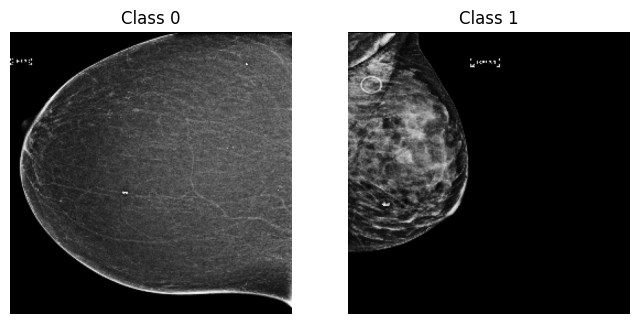

In [ ]:
import matplotlib.pyplot as plt
import cv2
import os

sample_0 = os.listdir(path + "/train/0")[0]
sample_1 = os.listdir(path + "/train/1")[0]

img0 = cv2.imread(path + "/train/0/" + sample_0)
img1 = cv2.imread(path + "/train/1/" + sample_1)

plt.figure(figsize=(8,4))

plt.subplot(1,2,1)
plt.imshow(cv2.cvtColor(img0, cv2.COLOR_BGR2RGB))
plt.title("Class 0")
plt.axis("off")

plt.subplot(1,2,2)
plt.imshow(cv2.cvtColor(img1, cv2.COLOR_BGR2RGB))
plt.title("Class 1")
plt.axis("off")

plt.show()

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN_DIR = path + "/train"
VAL_DIR   = path + "/valid"
TEST_DIR  = path + "/test"

train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)

Found 2372 images belonging to 2 classes.
Found 675 images belonging to 2 classes.
Found 336 images belonging to 2 classes.
Class mapping: {'0': 0, '1': 1}


In [ ]:
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weight_dict = dict(enumerate(class_weights))

print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(0.7558954748247291), 1: np.float64(1.4769613947696139)}


In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import tensorflow as tf

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling='avg'
)

# Freeze base first
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='sensitivity'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model.summary()

16705208/16705208 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,788 (16.70 MB)

 Trainable params: 328,705 (1.25 MB)

 Non-trainable params: 4,050,083 (15.45 MB)

In [ ]:
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_auc',
    patience=3,
    restore_best_weights=True
)

In [ ]:
history = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=[early_stop]
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 97s 898ms/step - accuracy: 0.4743 - auc: 0.4910 - loss: 0.7829 - precision: 0.3417 - sensitivity: 0.5226 - val_accuracy: 0.6637 - val_auc: 0.5000 - val_loss: 0.6856 - val_precision: 0.0000e+00 - val_sensitivity: 0.0000e+00
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 428ms/step - accuracy: 0.4826 - auc: 0.4763 - loss: 0.7497 - precision: 0.3027 - sensitivity: 0.4581 - val_accuracy: 0.6637 - val_auc: 0.5000 - val_loss: 0.6850 - val_precision: 0.0000e+00 - val_sensitivity: 0.0000e+00
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 31s 413ms/step - accuracy: 0.5022 - auc: 0.4947 - loss: 0.7380 - precision: 0.3227 - sensitivity: 0.4462 - val_accuracy: 0.3363 - val_auc: 0.4978 - val_loss: 0.7757 - val_precision: 0.3363 - val_sensitivity: 1.0000
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 427ms/step - accuracy: 0.5086 - auc: 0.4960 - loss: 0.7450 - precision: 0.3575 - sensitivity: 0.4811 - val_accuracy: 0.6637 - val_auc: 0.4967 - val_loss: 0.6502 - val_precision: 0.000

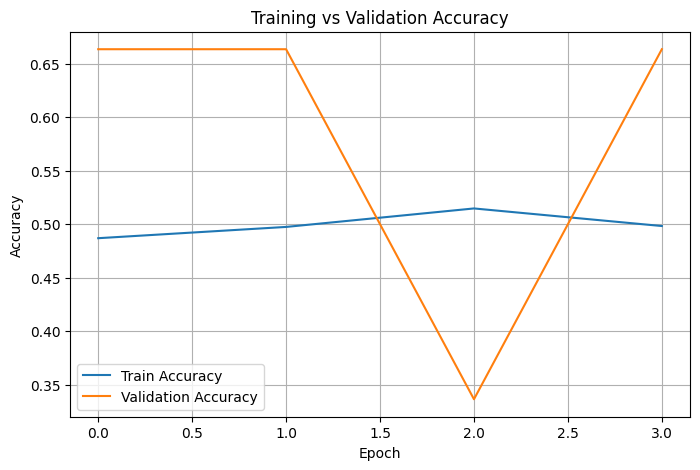

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

22/22 ━━━━━━━━━━━━━━━━━━━━ 22s 499ms/step


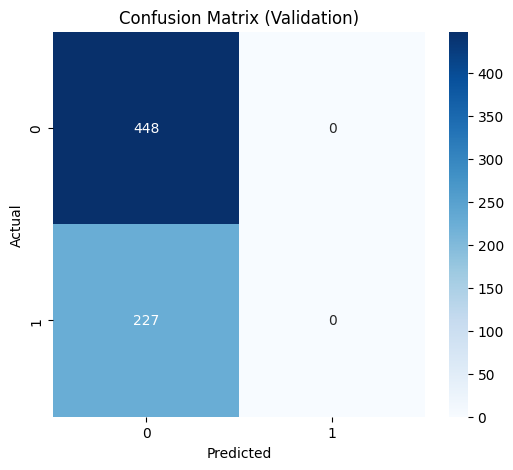

In [ ]:
import numpy as np
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get predictions
y_pred_prob = model.predict(val_generator)
y_pred = (y_pred_prob > 0.5).astype(int).ravel()
y_true = val_generator.classes

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['0','1'],
            yticklabels=['0','1'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix (Validation)')
plt.show()

In [ ]:
# finetuning

In [ ]:
# Unfreeze the base model
base_model.trainable = True

# Freeze early layers (keep last ~30% trainable)
for layer in base_model.layers[:-50]:
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),  # lower LR
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='sensitivity'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,788 (16.70 MB)

 Trainable params: 2,634,385 (10.05 MB)

 Non-trainable params: 1,744,403 (6.65 MB)

In [ ]:
history_ft = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1,
    class_weight=class_weight_dict
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 96s 799ms/step - accuracy: 0.4893 - auc: 0.5049 - loss: 0.9630 - precision: 0.3289 - sensitivity: 0.5166 - val_accuracy: 0.3363 - val_auc: 0.4978 - val_loss: 0.7196 - val_precision: 0.3363 - val_sensitivity: 1.0000
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 432ms/step - accuracy: 0.4828 - auc: 0.4797 - loss: 0.9161 - precision: 0.3052 - sensitivity: 0.4654 - val_accuracy: 0.3363 - val_auc: 0.5166 - val_loss: 0.8066 - val_precision: 0.3363 - val_sensitivity: 1.0000
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 427ms/step - accuracy: 0.4825 - auc: 0.4822 - loss: 0.9227 - precision: 0.3296 - sensitivity: 0.4769 - val_accuracy: 0.3363 - val_auc: 0.5387 - val_loss: 0.8745 - val_precision: 0.3363 - val_sensitivity: 1.0000
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 439ms/step - accuracy: 0.5012 - auc: 0.5271 - loss: 0.8659 - precision: 0.3408 - sensitivity: 0.5318 - val_accuracy: 0.3363 - val_auc: 0.5324 - val_loss: 0.9715 - val_precision: 0.3363 - val_sensitiv

In [ ]:
from PIL import Image
import os

sample = os.listdir(TRAIN_DIR + "/0")[0]
img = Image.open(TRAIN_DIR + "/0/" + sample)
print("Image size:", img.size)

Image size: (640, 640)


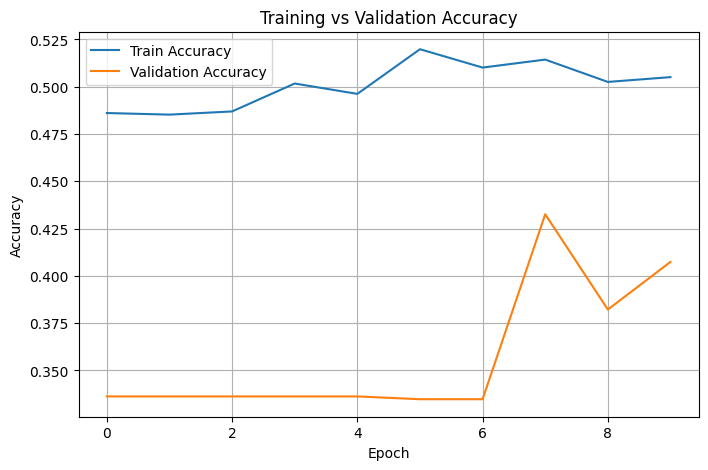

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_ft.history['accuracy'], label='Train Accuracy')
plt.plot(history_ft.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras import layers, models
import tensorflow as tf

base_model = EfficientNetB0(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),  # keep 224 for stability
    pooling='avg'
)

base_model.trainable = True

# Freeze first 100 layers
for layer in base_model.layers[:100]:
    layer.trainable = False

model = models.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='sensitivity'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ efficientnetb0 (Functional)     │ (None, 1280)           │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,378,788 (16.70 MB)

 Trainable params: 4,169,053 (15.90 MB)

 Non-trainable params: 209,735 (819.28 KB)

In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# ===== SETTINGS =====
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

TRAIN_DIR = path + "/train"
VAL_DIR   = path + "/valid"
TEST_DIR  = path + "/test"

# ===== DATA AUGMENTATION FOR TRAIN =====
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    zoom_range=0.1,
    horizontal_flip=True,
    width_shift_range=0.05,
    height_shift_range=0.05
)

# ===== ONLY RESCALE FOR VAL & TEST =====
val_test_datagen = ImageDataGenerator(rescale=1./255)

# ===== TRAIN GENERATOR =====
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

# ===== VALIDATION GENERATOR =====
val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

# ===== TEST GENERATOR =====
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

print("Class mapping:", train_generator.class_indices)
print("Train samples:", train_generator.samples)
print("Validation samples:", val_generator.samples)
print("Test samples:", test_generator.samples)

Found 2372 images belonging to 2 classes.
Found 675 images belonging to 2 classes.
Found 336 images belonging to 2 classes.
Class mapping: {'0': 0, '1': 1}
Train samples: 2372
Validation samples: 675
Test samples: 336


In [ ]:
history_ft1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1,
    class_weight=class_weight_dict
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 123s 979ms/step - accuracy: 0.5015 - auc: 0.5044 - loss: 0.9990 - precision: 0.3351 - sensitivity: 0.4760 - val_accuracy: 0.3363 - val_auc: 0.4930 - val_loss: 0.6971 - val_precision: 0.3363 - val_sensitivity: 1.0000
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 432ms/step - accuracy: 0.4947 - auc: 0.5104 - loss: 0.9387 - precision: 0.3308 - sensitivity: 0.5055 - val_accuracy: 0.3363 - val_auc: 0.4726 - val_loss: 0.7383 - val_precision: 0.3363 - val_sensitivity: 1.0000
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 42s 453ms/step - accuracy: 0.5024 - auc: 0.4906 - loss: 0.9812 - precision: 0.3265 - sensitivity: 0.4972 - val_accuracy: 0.3363 - val_auc: 0.4936 - val_loss: 0.9234 - val_precision: 0.3363 - val_sensitivity: 1.0000
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 461ms/step - accuracy: 0.5002 - auc: 0.5002 - loss: 0.9685 - precision: 0.3326 - sensitivity: 0.4734 - val_accuracy: 0.3319 - val_auc: 0.4558 - val_loss: 0.8488 - val_precision: 0.3333 - val_sensiti

In [ ]:
# Built CNN

In [ ]:
from tensorflow.keras import layers, models
import tensorflow as tf

model = models.Sequential([

    layers.Conv2D(32, (3,3), activation='relu', input_shape=(224,224,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(256, (3,3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(2,2),

    layers.GlobalAveragePooling2D(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='sensitivity'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 222, 222, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 109, 109, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 52, 52, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 24, 24, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_5           │ (None, 24, 24, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 256)            │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 423,361 (1.61 MB)

 Trainable params: 422,401 (1.61 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
history_cnn= model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    verbose=1,
    class_weight=class_weight_dict
)

Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 52s 541ms/step - accuracy: 0.5166 - auc: 0.5403 - loss: 0.7682 - precision: 0.3646 - sensitivity: 0.5623 - val_accuracy: 0.5985 - val_auc: 0.4677 - val_loss: 0.6820 - val_precision: 0.3197 - val_sensitivity: 0.1718
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 32s 428ms/step - accuracy: 0.5722 - auc: 0.5707 - loss: 0.7002 - precision: 0.3857 - sensitivity: 0.5304 - val_accuracy: 0.6637 - val_auc: 0.5641 - val_loss: 0.6728 - val_precision: 0.0000e+00 - val_sensitivity: 0.0000e+00
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 33s 438ms/step - accuracy: 0.5168 - auc: 0.5565 - loss: 0.6940 - precision: 0.3510 - sensitivity: 0.5602 - val_accuracy: 0.6637 - val_auc: 0.4737 - val_loss: 0.6505 - val_precision: 0.0000e+00 - val_sensitivity: 0.0000e+00
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 40s 428ms/step - accuracy: 0.5284 - auc: 0.5546 - loss: 0.6992 - precision: 0.3785 - sensitivity: 0.6165 - val_accuracy: 0.6637 - val_auc: 0.5046 - val_loss: 0.6476 - val_precision: 0.000

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix

# Get validation probabilities
y_val_prob = model.predict(val_generator).ravel()
y_val_true = val_generator.classes

# Compute ROC curve
fpr, tpr, thresholds = roc_curve(y_val_true, y_val_prob)

# Find threshold maximizing Youden’s index
youden_index = tpr - fpr
best_threshold = thresholds[np.argmax(youden_index)]

print("Best Threshold:", best_threshold)

22/22 ━━━━━━━━━━━━━━━━━━━━ 6s 162ms/step
Best Threshold: 0.43092597


In [ ]:
y_val_pred = (y_val_prob > best_threshold).astype(int)

cm = confusion_matrix(y_val_true, y_val_pred)
print(cm)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

[[173 275]
 [ 58 169]]
Sensitivity: 0.7444933920704846
Specificity: 0.3861607142857143


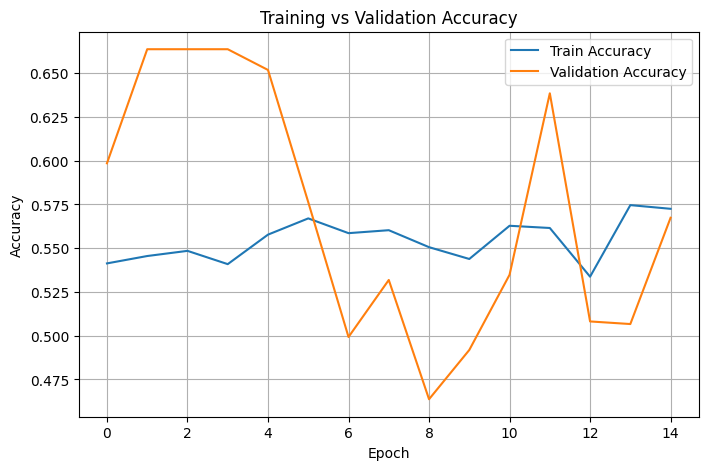

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_cnn.history['accuracy'], label='Train Accuracy')
plt.plot(history_cnn.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## DENSENET MODEL


In [ ]:
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras.applications.densenet import preprocess_input
from tensorflow.keras import layers, models
import numpy as np
from sklearn.utils.class_weight import compute_class_weight

In [ ]:
IMG_SIZE = (224, 224)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input,
    rotation_range=20,
    zoom_range=0.15,
    horizontal_flip=True
)

val_test_datagen = ImageDataGenerator(
    preprocessing_function=preprocess_input
)

train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary'
)

val_generator = val_test_datagen.flow_from_directory(
    VAL_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='binary',
    shuffle=False
)

Found 2372 images belonging to 2 classes.
Found 675 images belonging to 2 classes.
Found 336 images belonging to 2 classes.


In [ ]:
class_weights = compute_class_weight(
    class_weight='balanced',
    classes=np.unique(train_generator.classes),
    y=train_generator.classes
)

class_weight_dict = dict(enumerate(class_weights))
print("Class Weights:", class_weight_dict)

Class Weights: {0: np.float64(0.7558954748247291), 1: np.float64(1.4769613947696139)}


In [ ]:
base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling='avg'
)

# Unfreeze entire network for medical fine-tuning
base_model.trainable = True

model = models.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

29084464/29084464 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-6),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='sensitivity'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model.summary()

Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,185 (27.85 MB)

 Trainable params: 7,217,025 (27.53 MB)

 Non-trainable params: 84,160 (328.75 KB)

In [ ]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_auc',
        patience=5,
        mode='max',
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc',
        factor=0.3,
        patience=2,
        mode='max'
    )
]

In [ ]:
history_dt = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=15,
    verbose=1,
    class_weight=class_weight_dict,
    callbacks=callbacks
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 476s 4s/step - accuracy: 0.5185 - auc: 0.5129 - loss: 1.0600 - precision: 0.3489 - sensitivity: 0.5226 - val_accuracy: 0.6459 - val_auc: 0.5486 - val_loss: 0.6834 - val_precision: 0.4062 - val_sensitivity: 0.1145 - learning_rate: 1.0000e-06
Epoch 2/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 40s 535ms/step - accuracy: 0.4972 - auc: 0.4968 - loss: 1.0594 - precision: 0.3317 - sensitivity: 0.4960 - val_accuracy: 0.5896 - val_auc: 0.5603 - val_loss: 0.6953 - val_precision: 0.3626 - val_sensitivity: 0.2907 - learning_rate: 1.0000e-06
Epoch 3/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 39s 520ms/step - accuracy: 0.5054 - auc: 0.5082 - loss: 1.0418 - precision: 0.3518 - sensitivity: 0.5141 - val_accuracy: 0.5867 - val_auc: 0.5601 - val_loss: 0.7317 - val_precision: 0.3839 - val_sensitivity: 0.3789 - learning_rate: 1.0000e-06
Epoch 4/15
75/75 ━━━━━━━━━━━━━━━━━━━━ 40s 529ms/step - accuracy: 0.5167 - auc: 0.5387 - loss: 0.9735 - precision: 0.3552 - sensitivity: 0.5433 - val_accuracy: 

In [ ]:
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=IMG_SIZE,
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

results = model.evaluate(test_generator)
print("Test Results:", results)

Found 336 images belonging to 2 classes.
11/11 ━━━━━━━━━━━━━━━━━━━━ 15s 1s/step - accuracy: 0.4578 - auc: 0.2468 - loss: 0.9428 - precision: 0.1209 - sensitivity: 0.2181
Test Results: [0.9030898213386536, 0.4702380895614624, 0.501878023147583, 0.46875, 0.3529411852359772]


In [ ]:
from tensorflow.keras.applications import DenseNet121
from tensorflow.keras import layers, models
import tensorflow as tf

base_model = DenseNet121(
    include_top=False,
    weights='imagenet',
    input_shape=(224, 224, 3),
    pooling='avg'
)

# Freeze backbone
base_model.trainable = False

model = models.Sequential([
    base_model,
    layers.Dense(256, activation='relu'),
    layers.BatchNormalization(),
    layers.Dropout(0.5),
    layers.Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='sensitivity'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ densenet121 (Functional)        │ (None, 1024)           │     7,037,504 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 256)            │       262,400 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 256)            │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,301,185 (27.85 MB)

 Trainable params: 263,169 (1.00 MB)

 Non-trainable params: 7,038,016 (26.85 MB)

In [ ]:
history_phase1 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1,
    class_weight=class_weight_dict
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 96s 914ms/step - accuracy: 0.4994 - auc: 0.5017 - loss: 0.9780 - precision: 0.3435 - sensitivity: 0.5123 - val_accuracy: 0.4519 - val_auc: 0.5704 - val_loss: 0.7759 - val_precision: 0.3648 - val_sensitivity: 0.8502
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 450ms/step - accuracy: 0.5540 - auc: 0.5673 - loss: 0.8339 - precision: 0.3953 - sensitivity: 0.5632 - val_accuracy: 0.5126 - val_auc: 0.5899 - val_loss: 0.7071 - val_precision: 0.3672 - val_sensitivity: 0.6211
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 466ms/step - accuracy: 0.5384 - auc: 0.5738 - loss: 0.8242 - precision: 0.3836 - sensitivity: 0.5892 - val_accuracy: 0.5319 - val_auc: 0.5996 - val_loss: 0.7279 - val_precision: 0.3896 - val_sensitivity: 0.6916
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 458ms/step - accuracy: 0.5609 - auc: 0.5816 - loss: 0.8096 - precision: 0.3904 - sensitivity: 0.5761 - val_accuracy: 0.5156 - val_auc: 0.6065 - val_loss: 0.7406 - val_precision: 0.3869 - val_sensitiv

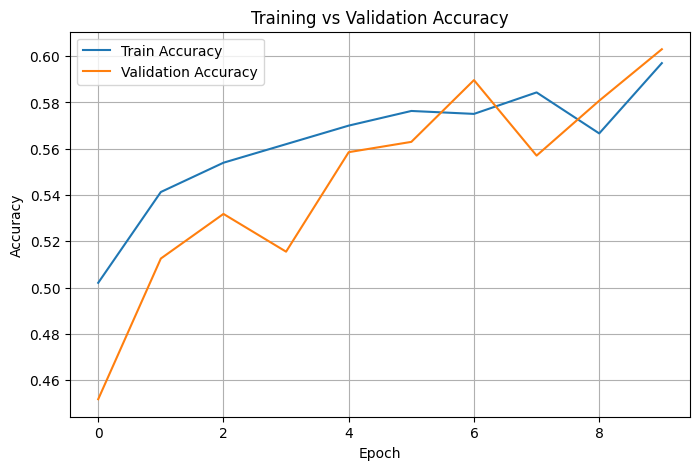

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_phase1.history['accuracy'], label='Train Accuracy')
plt.plot(history_phase1.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

# Phase 2

In [ ]:
# Unfreeze last 40 layers
for layer in base_model.layers[-40:]:
    layer.trainable = True

# Keep earlier layers frozen
for layer in base_model.layers[:-40]:
    layer.trainable = False

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Recall(name='sensitivity'),
        tf.keras.metrics.Precision(name='precision')
    ]
)

In [ ]:
history_phase2 = model.fit(
    train_generator,
    validation_data=val_generator,
    epochs=10,
    verbose=1,
    class_weight=class_weight_dict
)

Epoch 1/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 112s 1s/step - accuracy: 0.5644 - auc: 0.6054 - loss: 0.7861 - precision: 0.4142 - sensitivity: 0.5842 - val_accuracy: 0.5704 - val_auc: 0.6085 - val_loss: 0.7213 - val_precision: 0.4060 - val_sensitivity: 0.5991
Epoch 2/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 444ms/step - accuracy: 0.6050 - auc: 0.6385 - loss: 0.7463 - precision: 0.4516 - sensitivity: 0.6201 - val_accuracy: 0.5526 - val_auc: 0.5995 - val_loss: 0.7485 - val_precision: 0.3955 - val_sensitivity: 0.6256
Epoch 3/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 35s 467ms/step - accuracy: 0.5945 - auc: 0.6500 - loss: 0.7162 - precision: 0.4128 - sensitivity: 0.6516 - val_accuracy: 0.5585 - val_auc: 0.5995 - val_loss: 0.7458 - val_precision: 0.3971 - val_sensitivity: 0.6035
Epoch 4/10
75/75 ━━━━━━━━━━━━━━━━━━━━ 34s 458ms/step - accuracy: 0.6057 - auc: 0.6601 - loss: 0.7062 - precision: 0.4562 - sensitivity: 0.6266 - val_accuracy: 0.5793 - val_auc: 0.5995 - val_loss: 0.7386 - val_precision: 0.4107 - val_sensitivit

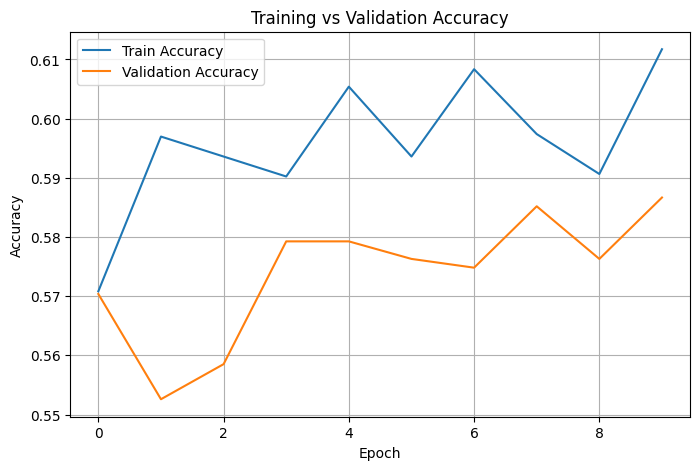

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.plot(history_phase2.history['accuracy'], label='Train Accuracy')
plt.plot(history_phase2.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.title('Training vs Validation Accuracy')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
import numpy as np
from sklearn.metrics import roc_curve, confusion_matrix, roc_auc_score

y_val_prob = model.predict(val_generator).ravel()
y_val_true = val_generator.classes

print("Validation AUC:", roc_auc_score(y_val_true, y_val_prob))

22/22 ━━━━━━━━━━━━━━━━━━━━ 28s 704ms/step
Validation AUC: 0.6204570484581498


In [ ]:
fpr, tpr, thresholds = roc_curve(y_val_true, y_val_prob)

youden_index = tpr - fpr
best_threshold = thresholds[np.argmax(youden_index)]

print("Best Threshold:", best_threshold)

Best Threshold: 0.52129877


In [ ]:
y_val_pred = (y_val_prob > best_threshold).astype(int)

cm = confusion_matrix(y_val_true, y_val_pred)
print(cm)

TN, FP, FN, TP = cm.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Sensitivity:", sensitivity)
print("Specificity:", specificity)

[[273 175]
 [ 92 135]]
Sensitivity: 0.5947136563876652
Specificity: 0.609375


In [ ]:
test_generator = val_test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(224, 224),
    batch_size=32,
    class_mode='binary',
    shuffle=False
)

results = model.evaluate(test_generator)

print("Test Loss:", results[0])
print("Test Accuracy:", results[1])
print("Test AUC:", results[2])
print("Test Sensitivity:", results[3])
print("Test Precision:", results[4])

Found 336 images belonging to 2 classes.


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 1s/step - accuracy: 0.5963 - auc: 0.3252 - loss: 0.7386 - precision: 0.1866 - sensitivity: 0.3342  
Test Loss: 0.7188096642494202
Test Accuracy: 0.6071428656578064
Test AUC: 0.6260328888893127
Test Sensitivity: 0.609375
Test Precision: 0.48750001192092896


In [ ]:
from sklearn.metrics import roc_auc_score

y_test_prob = model.predict(test_generator).ravel()
y_test_true = test_generator.classes

print("Test ROC AUC:", roc_auc_score(y_test_true, y_test_prob))

11/11 ━━━━━━━━━━━━━━━━━━━━ 10s 933ms/step
Test ROC AUC: 0.6257887620192307


In [ ]:
from sklearn.metrics import confusion_matrix

y_test_pred = (y_test_prob > best_threshold).astype(int)

cm_test = confusion_matrix(y_test_true, y_test_pred)
print(cm_test)

TN, FP, FN, TP = cm_test.ravel()

sensitivity = TP / (TP + FN)
specificity = TN / (TN + FP)

print("Test Sensitivity:", sensitivity)
print("Test Specificity:", specificity)

[[134  74]
 [ 54  74]]
Test Sensitivity: 0.578125
Test Specificity: 0.6442307692307693


In [ ]:
import os

# Pick one cancer image
cancer_img_path = os.path.join(TEST_DIR, "1", os.listdir(TEST_DIR + "/1")[0])

# Pick one normal image
normal_img_path = os.path.join(TEST_DIR, "0", os.listdir(TEST_DIR + "/0")[0])

print("Cancer image path:", cancer_img_path)
print("Normal image path:", normal_img_path)

Cancer image path: /root/.cache/kagglehub/datasets/hayder17/breast-cancer-detection/versions/1/test/1/31964_488598184_png.rf.d886bc1248670f56f63fa44b62378968.jpg
Normal image path: /root/.cache/kagglehub/datasets/hayder17/breast-cancer-detection/versions/1/test/0/3015_281183511_png.rf.dc286e067119e96dd8e38ac46faaa9cf.jpg


In [ ]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from tensorflow.keras.applications.densenet import preprocess_input

def predict_image(img_path, threshold=0.5):
    img = cv2.imread(img_path)
    img_rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    img_resized = cv2.resize(img_rgb, (224, 224))
    img_array = np.expand_dims(img_resized, axis=0)
    img_array = preprocess_input(img_array)

    prob = model.predict(img_array)[0][0]
    pred = 1 if prob > threshold else 0

    plt.imshow(img_rgb)
    plt.title(f"Prediction: {pred} | Probability: {prob:.4f}")
    plt.axis("off")
    plt.show()

    return prob

1/1 ━━━━━━━━━━━━━━━━━━━━ 13s 13s/step


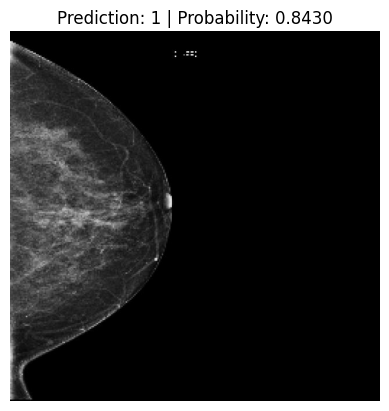

np.float32(0.84300554)

In [ ]:
predict_image(cancer_img_path, threshold=best_threshold)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step


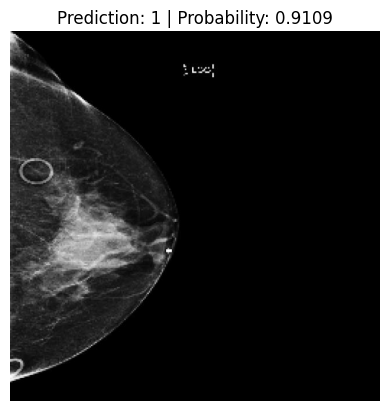

np.float32(0.9109293)

In [ ]:
predict_image(normal_img_path, threshold=best_threshold)